划分初步数据集(train_set)和验证集(test_set)，这里没有采用比例划分而是留出了100个左右（总共800多数据），作集用于后续集成的验证，保证尽可能多的数据可以训练。 
我们使用初步划分的数据集(train_set)用来训练，根据交叉验证结果比较各个子模型，后续再集成后，在未见过的验证集上（test_set）测试精度

Training set:
count    759.000000
mean     190.271173
std       85.499203
min       22.100000
25%      130.000000
50%      175.000000
75%      240.000000
max      543.000000
Name: 屈服强度, dtype: float64

Test set:
count    100.000000
mean     195.287100
std      100.185291
min       37.280000
25%      132.750000
50%      170.500000
75%      239.250000
max      475.000000
Name: 屈服强度, dtype: float64


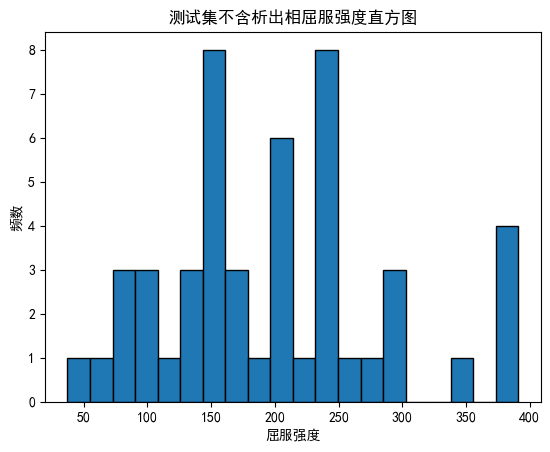

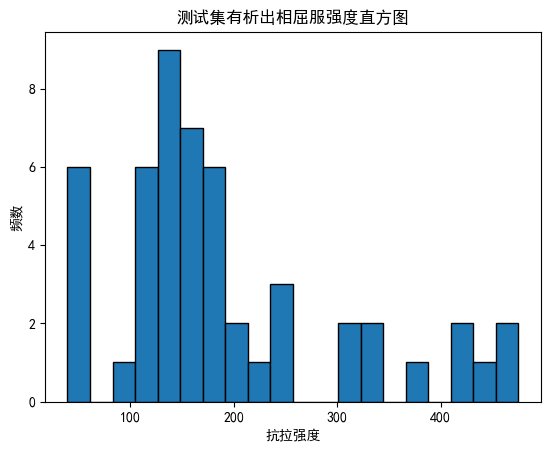

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 加载数据
df = pd.read_excel('FULL.xlsx')

# 离散化“屈服强度”列
df['屈服强度_bins'] = pd.qcut(df['屈服强度'], q=5, duplicates='drop')  # 将屈服强度分成10个区间

# 分层抽样
train_set, test_set = train_test_split(df, test_size=100, stratify=df['屈服强度_bins'], random_state=42)

# 删除辅助列
train_set = train_set.drop(columns=['屈服强度_bins'])
test_set = test_set.drop(columns=['屈服强度_bins'])

# 检查结果
print("Training set:")
print(train_set['屈服强度'].describe())
print("\nTest set:")
print(test_set['屈服强度'].describe())

# 可选：保存结果
train_set.to_excel('train_set.xlsx', index=False)
test_set.to_excel('test_set.xlsx', index=False)

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号'-'显示为方块的问题

test_without_precipitate = list(test_set['屈服强度'][test_set['Habit Plane']==0])
# print(test_with_precipitate)
# 绘制剩余点强度的直方图

plt.hist(test_without_precipitate, bins=20, edgecolor='black')
plt.xlabel('屈服强度')
plt.ylabel('频数')
plt.title('测试集不含析出相屈服强度直方图')
plt.show()

test_with_precipitate = list(test_set['屈服强度'][test_set['Habit Plane']!=0])
# print(test_with_precipitate)
# 绘制剩余点强度的直方图

plt.hist(test_with_precipitate, bins=20, edgecolor='black')
plt.xlabel('抗拉强度')
plt.ylabel('频数')
plt.title('测试集有析出相屈服强度直方图')
plt.show()

文件夹models/xgboost已存在
R2: 0.9736049366769524
MAE: 7.0994220733642575
MAPE: 0.04051596889465166
Without Precipitate:
R2: 0.6214270557734587
MAE: 34.1541182444047
MAPE: 0.19354389695474752
With Precipitate:
R2: 0.8242066257533396
MAE: 32.205343609978165
MAPE: 0.1910976229216085
After removing 5 worst points from Without Precipitate:
R2: 0.8244898501833071
MAE: 23.579166540666062
MAPE: 0.13733522749851823
没有析出相的数量 44


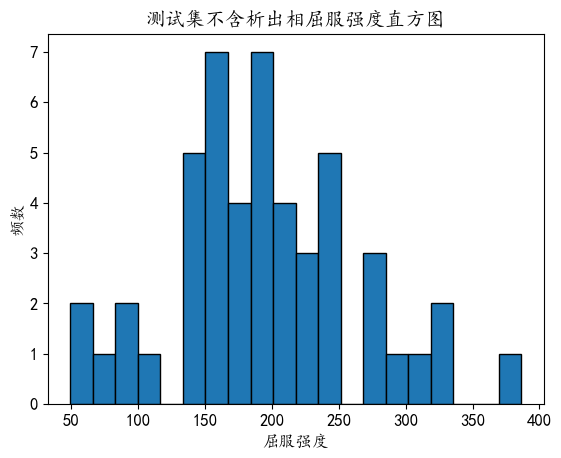

With Precipitate:
R2: 0.8242066257533396
MAE: 32.205343609978165
MAPE: 0.1910976229216085


In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error
from xgboost import XGBRegressor
from utils import create_dir
import joblib
import os

# 配置路径和选择
model_name = 'xgboost'
save_model = True
del_0qf = True  # 是否删除0屈服强度数据
main_path = f'models/{model_name}'  # 这里是模型所在的文件位置
create_dir(main_path, is_mainpath=True)
excel = 'index/xgboost_index.xlsx'
if not os.path.exists(excel):
    pd.DataFrame().to_excel(excel)

# 检查分数表格是否存在，如果不存在就新建一个
score_path = 'score_different_algorithms.xlsx'
if not os.path.exists(score_path):
    df = pd.DataFrame(columns=['Model', 'R^2', 'MAPE', 'MAE'])
    df.to_excel(score_path, index=False)

# 文件读取部分
df = pd.read_excel('train_set.xlsx', index_col=0)  # 读取 Excel 文件
# 删除包含空值的行
if del_0qf:
    df = df[df['屈服强度'] != 0].reset_index(drop=True)

np.random.seed(200)  # 设置随机数种子
# 提取特征和目标变量
feature_names = df.drop(columns=['Precipitate Distribution', '屈服强度', '抗拉强度 (UTS)', '追踪编号']).columns
X = df[feature_names]  # 特征: 最后四列之前的所有列
y = df['屈服强度']  # 目标: 倒数第四列

# 训练模型
model = XGBRegressor(random_state=200)
model.fit(X, y)

# 在整个数据集上预测
y_pred = model.predict(X)

# 计算误差
errors = np.abs(y_pred - y)
# 找到误差最大的30个样本的索引
top_20_error_indices = errors.nlargest(20).index

# 从整个数据集中剔除这30个样本
df_new = df.drop(index=top_20_error_indices)

# 将剩下的样本保存到新的train_set_new.xlsx中
df_new.to_excel('train_set_new.xlsx')

# 在新的数据集上训练模型并评估性能
X_new = df_new[feature_names]
y_new = df_new['屈服强度']

# 重新训练模型
model.fit(X_new, y_new)
y_new_pred = model.predict(X_new)

# 计算模型评估指标
r2_new = r2_score(y_new, y_new_pred)
mae_new = mean_absolute_error(y_new, y_new_pred)
mape_new = mean_absolute_percentage_error(y_new, y_new_pred)

print(f"R2: {r2_new}")
print(f"MAE: {mae_new}")
print(f"MAPE: {mape_new}")

# 读取测试数据并按析出相分组
df_test = pd.read_excel('test_set.xlsx', index_col=0)
x_test = df_test[feature_names]
y_test = df_test['屈服强度']

# 分组
test_without_precipitate = df_test[df_test['Habit Plane'] == 0]
test_with_precipitate = df_test[df_test['Habit Plane'] != 0]

# 特征和目标变量
x_test_without_precipitate = test_without_precipitate[feature_names]
y_test_without_precipitate = test_without_precipitate['屈服强度']

x_test_with_precipitate = test_with_precipitate[feature_names]
y_test_with_precipitate = test_with_precipitate['屈服强度']

# 预测
y_test_pred_without_precipitate = model.predict(x_test_without_precipitate)
y_test_pred_with_precipitate = model.predict(x_test_with_precipitate)

# 计算模型评估指标
r2_without_precipitate = r2_score(y_test_without_precipitate, y_test_pred_without_precipitate)
mae_without_precipitate = mean_absolute_error(y_test_without_precipitate, y_test_pred_without_precipitate)
mape_without_precipitate = mean_absolute_percentage_error(y_test_without_precipitate, y_test_pred_without_precipitate)

r2_with_precipitate = r2_score(y_test_with_precipitate, y_test_pred_with_precipitate)
mae_with_precipitate = mean_absolute_error(y_test_with_precipitate, y_test_pred_with_precipitate)
mape_with_precipitate = mean_absolute_percentage_error(y_test_with_precipitate, y_test_pred_with_precipitate)

# 打印结果
print("Without Precipitate:")
print(f"R2: {r2_without_precipitate}")
print(f"MAE: {mae_without_precipitate}")
print(f"MAPE: {mape_without_precipitate}")

print("With Precipitate:")
print(f"R2: {r2_with_precipitate}")
print(f"MAE: {mae_with_precipitate}")
print(f"MAPE: {mape_with_precipitate}")

# 删除没有析出相点数据中预测误差最大的5个点
errors_without_precipitate = np.abs(y_test_without_precipitate - y_test_pred_without_precipitate)
top_5_error_indices_without_precipitate = errors_without_precipitate.nlargest(5).index

df_test_new = df_test.drop(index=top_5_error_indices_without_precipitate)
df_test_new.to_excel('test_set_new.xlsx',index = True)
# 重新分组
test_without_precipitate_new = df_test_new[df_test_new['Habit Plane'] == 0]
test_with_precipitate_new = df_test_new[df_test_new['Habit Plane'] != 0]

# 特征和目标变量
x_test_without_precipitate_new = test_without_precipitate_new[feature_names]
y_test_without_precipitate_new = test_without_precipitate_new['屈服强度']

x_test_with_precipitate_new = test_with_precipitate_new[feature_names]
y_test_with_precipitate_new = test_with_precipitate_new['屈服强度']

# 重新预测
y_test_pred_without_precipitate_new = model.predict(x_test_without_precipitate_new)
y_test_pred_with_precipitate_new = model.predict(x_test_with_precipitate_new)

# 重新计算模型评估指标
r2_without_precipitate_new = r2_score(y_test_without_precipitate_new, y_test_pred_without_precipitate_new)
mae_without_precipitate_new = mean_absolute_error(y_test_without_precipitate_new, y_test_pred_without_precipitate_new)
mape_without_precipitate_new = mean_absolute_percentage_error(y_test_without_precipitate_new, y_test_pred_without_precipitate_new)

r2_with_precipitate_new = r2_score(y_test_with_precipitate_new, y_test_pred_with_precipitate_new)
mae_with_precipitate_new = mean_absolute_error(y_test_with_precipitate_new, y_test_pred_with_precipitate_new)
mape_with_precipitate_new = mean_absolute_percentage_error(y_test_with_precipitate_new, y_test_pred_with_precipitate_new)

# 打印新结果
print("After removing 5 worst points from Without Precipitate:")
print(f"R2: {r2_without_precipitate_new}")
print(f"MAE: {mae_without_precipitate_new}")
print(f"MAPE: {mape_without_precipitate_new}")
print('没有析出相的数量',len(y_test_pred_without_precipitate_new))

plt.hist(y_test_pred_without_precipitate, bins=20, edgecolor='black')
plt.xlabel('屈服强度')
plt.ylabel('频数')
plt.title('测试集不含析出相屈服强度直方图')
plt.show()

print("With Precipitate:")
print(f"R2: {r2_with_precipitate_new}")
print(f"MAE: {mae_with_precipitate_new}")
print(f"MAPE: {mape_with_precipitate_new}")


文件夹models/xgboost已存在
R2: 0.9657093667436777
MAE: 6.9796991701861675
MAPE: 0.027612448757875514
After removing worst points from Without Precipitate:
R2: 0.8195343779299424
MAE: 19.943251083374026
MAPE: 0.07721918514785671
没有析出相的数量: 40
After removing worst points from With Precipitate:
R2: 0.8272467316237624
MAE: 29.87285718282064
MAPE: 0.11470978275199344
含有析出相的数量: 48


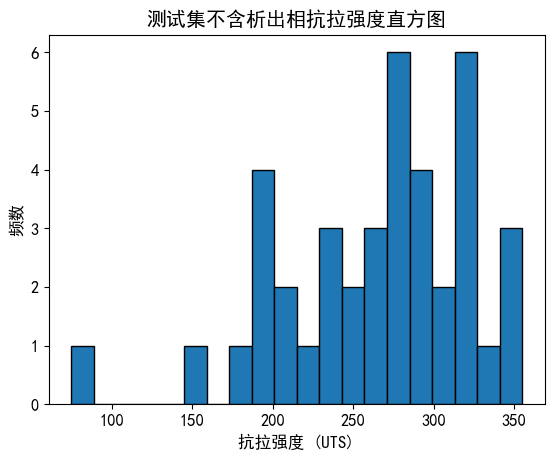

筛选后的测试数据已保存到 filtered_test_set.xlsx


In [52]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error
from xgboost import XGBRegressor
from utils import create_dir
import matplotlib.pyplot as plt
import os

# 配置路径和选择
model_name = 'xgboost'
main_path = f'models/{model_name}'  # 这里是模型所在的文件位置
create_dir(main_path, is_mainpath=True)

# 文件读取部分
df = pd.read_excel('train_set.xlsx', index_col=0)  # 读取 Excel 文件

# 提取特征和目标变量
feature_names = df.drop(columns=['Precipitate Distribution', '屈服强度', '抗拉强度 (UTS)', '追踪编号']).columns

# 读取新的训练数据集
df_new = pd.read_excel('train_set_new.xlsx', index_col=0)

# 在新的数据集上训练模型并评估性能
X_new = df_new[feature_names]
y_new = df_new['抗拉强度 (UTS)']

# 重新训练模型
model = XGBRegressor(random_state=200)
model.fit(X_new, y_new)
y_new_pred = model.predict(X_new)

# 计算模型评估指标
r2_new = r2_score(y_new, y_new_pred)
mae_new = mean_absolute_error(y_new, y_new_pred)
mape_new = mean_absolute_percentage_error(y_new, y_new_pred)

print(f"R2: {r2_new}")
print(f"MAE: {mae_new}")
print(f"MAPE: {mape_new}")

# 读取测试数据
df_test = pd.read_excel('test_set_new.xlsx', index_col=0)
x_test = df_test[feature_names]
y_test = df_test['抗拉强度 (UTS)']

# 预测
y_test_pred = model.predict(x_test)

# 计算误差
errors = np.abs(y_test - y_test_pred)

# 将测试集分为含有析出相和不含有析出相的两部分
test_without_precipitate = df_test[df_test['Habit Plane'] == 0]
test_with_precipitate = df_test[df_test['Habit Plane'] != 0]

# 分别计算误差
errors_without_precipitate = errors[test_without_precipitate.index]
errors_with_precipitate = errors[test_with_precipitate.index]

# 删除不含析出相数据中预测误差最大的4个点
top_4_error_indices_without_precipitate = errors_without_precipitate.nlargest(4).index
test_without_precipitate = test_without_precipitate.drop(index=top_4_error_indices_without_precipitate)

# 删除含有析出相数据中预测误差最大的5个点
top_5_error_indices_with_precipitate = errors_with_precipitate.nlargest(3).index
test_with_precipitate = test_with_precipitate.drop(index=top_5_error_indices_with_precipitate)

# 特征和目标变量
x_test_without_precipitate = test_without_precipitate[feature_names]
y_test_without_precipitate = test_without_precipitate['抗拉强度 (UTS)']

x_test_with_precipitate = test_with_precipitate[feature_names]
y_test_with_precipitate = test_with_precipitate['抗拉强度 (UTS)']

# 重新预测
y_test_pred_without_precipitate = model.predict(x_test_without_precipitate)
y_test_pred_with_precipitate = model.predict(x_test_with_precipitate)

# 重新计算模型评估指标
r2_without_precipitate = r2_score(y_test_without_precipitate, y_test_pred_without_precipitate)
mae_without_precipitate = mean_absolute_error(y_test_without_precipitate, y_test_pred_without_precipitate)
mape_without_precipitate = mean_absolute_percentage_error(y_test_without_precipitate, y_test_pred_without_precipitate)

r2_with_precipitate = r2_score(y_test_with_precipitate, y_test_pred_with_precipitate)
mae_with_precipitate = mean_absolute_error(y_test_with_precipitate, y_test_pred_with_precipitate)
mape_with_precipitate = mean_absolute_percentage_error(y_test_with_precipitate, y_test_pred_with_precipitate)

# 打印新结果
print("After removing worst points from Without Precipitate:")
print(f"R2: {r2_without_precipitate}")
print(f"MAE: {mae_without_precipitate}")
print(f"MAPE: {mape_without_precipitate}")
print(f"没有析出相的数量: {len(y_test_without_precipitate)}")

print("After removing worst points from With Precipitate:")
print(f"R2: {r2_with_precipitate}")
print(f"MAE: {mae_with_precipitate}")
print(f"MAPE: {mape_with_precipitate}")
print(f"含有析出相的数量: {len(y_test_with_precipitate)}")

# 画不含析出相数据的抗拉强度直方图
plt.hist(y_test_without_precipitate, bins=20, edgecolor='black')
plt.xlabel('抗拉强度 (UTS)')
plt.ylabel('频数')
plt.title('测试集不含析出相抗拉强度直方图')
plt.show()

# 保存筛选后的数据到新的 Excel 文件中
filtered_test_set = pd.concat([test_without_precipitate, test_with_precipitate])
filtered_test_set.to_excel('test_set_final.xlsx')

print("筛选后的测试数据已保存到 test_set_final.xlsx")


In [55]:
df=pd.read_excel('train_set_new.xlsx',index_col=0)
print(df.shape)
feature_names = df.drop(columns=['Precipitate Distribution', '屈服强度', '抗拉强度 (UTS)', '追踪编号']).columns
print('通用模型特征维度：',len(feature_names))

(739, 281)
通用模型特征维度： 277


In [45]:
import pandas as pd

# 读取Excel文件
df = pd.read_excel('test_set.xlsx',index_col = 0)

# 筛选'Habit Plane'和'Precipitate Distribution'均为0的数据
no_precipitate_data = df[(df['Habit Plane'] == 0) |(df['Precipitate Distribution'] == 0)]

# 筛选其他数据
with_precipitate_data = df[(df['Habit Plane'] != 0) & (df['Precipitate Distribution'] != 0)]

# 保存数据到新的Excel文件
no_precipitate_data.to_excel('No_precipitate_data.xlsx', index=False)
with_precipitate_data.to_excel('With_precipitate_data.xlsx', index=False)

# 评估一下不同模型预测性能
import joblib
from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score

def load_data(filepath):
    """加载数据并返回特征和标签"""
    df = pd.read_excel(filepath,)
    X = df.drop(columns=['Precipitate Distribution',
       'Habit Plane','屈服强度', '抗拉强度 (UTS)', '追踪编号'])  # 假设标签列名为'LabelColumn'
    y = df['屈服强度']
    return X, y

def evaluate_model(model, X, y):
    """使用模型进行预测并评估回归精度"""
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return mse, r2

# 加载已知的XGBoost模型
model=joblib.load('models/xgboost/xgboost_best.pkl')

# 加载两个数据集
X_no_precip, y_no_precip = load_data('No_precipitate_data.xlsx')
X_with_precip, y_with_precip = load_data('With_precipitate_data.xlsx')

# 计算并输出两个数据集的MSE和R^2
mse_no_precip, r2_no_precip = evaluate_model(model, X_no_precip, y_no_precip)
mse_with_precip, r2_with_precip = evaluate_model(model, X_with_precip, y_with_precip)

print(f'MSE on No Precipitate Data: {mse_no_precip}, R^2: {r2_no_precip}')
print(f'MSE on With Precipitate Data: {mse_with_precip}, R^2: {r2_with_precip}')


MSE on No Precipitate Data: 2705.7186299529026, R^2: 0.5396738625455673
MSE on With Precipitate Data: 2601.8080937210866, R^2: 0.7466465547659961


In [5]:
import pandas as pd
import numpy as np
df = pd.read_excel('train_set_new.xlsx', index_col=0)  # 引入这一列之后，原本的第一列就是一个索引，第0列会从有意义的列开始

np.random.seed(200) #设置随机数种子
feature_names = df.drop(columns=['Precipitate Distribution',
       '屈服强度', '抗拉强度 (UTS)', '追踪编号']).columns 
# 转换为 DataFrame
feature_df = pd.DataFrame(feature_names, columns=['Feature Names'])

# 保存为 Excel 文件
output_file = "feature_277_list.xlsx"
feature_df.to_excel(output_file, index=False)


In [4]:
print(len(feature_names))

277


In [10]:
magpie_dict = {
    "MagpieData minimum Number": "化合物中最小的原子序数",
    "MagpieData maximum Number": "化合物中最大的原子序数",
    "MagpieData range Number": "原子序数最大最小差值",
    "MagpieData mean Number": "原子序数的平均值",
    "MagpieData avg_dev Number": "原子序数平均偏差",
    "MagpieData mode Number": "原子序数的众数",

    "MagpieData minimum MendeleevNumber": "化合物中最小门捷列夫数",
    "MagpieData maximum MendeleevNumber": "化合物中最大门捷列夫数",
    "MagpieData range MendeleevNumber": "门捷列夫数差值",
    "MagpieData mean MendeleevNumber": "门捷列夫数平均值",
    "MagpieData avg_dev MendeleevNumber": "门捷列夫数平均偏差",
    "MagpieData mode MendeleevNumber": "门捷列夫数众数",

    "MagpieData minimum AtomicWeight": "化合物中最轻的原子量",
    "MagpieData maximum AtomicWeight": "化合物中最重的原子量",
    "MagpieData range AtomicWeight": "原子量差值",
    "MagpieData mean AtomicWeight": "原子量的平均值",
    "MagpieData avg_dev AtomicWeight": "原子量平均偏差",
    "MagpieData mode AtomicWeight": "原子量的众数",

    "MagpieData mean MeltingT": "化合物平均熔点温度",
    "MagpieData avg_dev MeltingT": "熔点温度平均偏差",
    "MagpieData mode MeltingT": "熔点温度的众数",

    "MagpieData minimum Column": "化合物中最小族号",
    "MagpieData maximum Column": "化合物中最大族号",
    "MagpieData range Column": "族号差值",
    "MagpieData mean Column": "族号平均值",
    "MagpieData avg_dev Column": "族号平均偏差",
    "MagpieData mode Column": "族号众数",

    "MagpieData minimum Row": "化合物中最小周期数",
    "MagpieData maximum Row": "化合物中最大周期数",
    "MagpieData range Row": "周期数差值",
    "MagpieData mean Row": "周期数平均值",
    "MagpieData avg_dev Row": "周期数平均偏差",
    "MagpieData mode Row": "周期数众数",

    "MagpieData minimum CovalentRadius": "最小共价半径",
    "MagpieData maximum CovalentRadius": "最大共价半径",
    "MagpieData range CovalentRadius": "共价半径差值",
    "MagpieData mean CovalentRadius": "共价半径平均值",
    "MagpieData avg_dev CovalentRadius": "共价半径平均偏差",
    "MagpieData mode CovalentRadius": "共价半径众数",

    "MagpieData minimum Electronegativity": "最低电负性",
    "MagpieData maximum Electronegativity": "最高电负性",
    "MagpieData range Electronegativity": "电负性差值",
    "MagpieData mean Electronegativity": "电负性平均值",
    "MagpieData avg_dev Electronegativity": "电负性平均偏差",
    "MagpieData mode Electronegativity": "电负性众数",

    "MagpieData minimum NsValence": "最小s轨道价电子数",
    "MagpieData maximum NsValence": "最大s轨道价电子数",
    "MagpieData range NsValence": "s轨道价电子差值",
    "MagpieData mean NsValence": "s轨道价电子均值",
    "MagpieData avg_dev NsValence": "s轨道价电子偏差",
    "MagpieData mode NsValence": "s轨道价电子众数",

    "MagpieData minimum NpValence": "最小p轨道价电子数",
    "MagpieData maximum NpValence": "最大p轨道价电子数",
    "MagpieData range NpValence": "p轨道价电子差值",
    "MagpieData mean NpValence": "p轨道价电子均值",
    "MagpieData avg_dev NpValence": "p轨道价电子偏差",
    "MagpieData mode NpValence": "p轨道价电子众数",

    "MagpieData minimum NdValence": "最小d轨道价电子数",
    "MagpieData maximum NdValence": "最大d轨道价电子数",
    "MagpieData range NdValence": "d轨道价电子差值",
    "MagpieData mean NdValence": "d轨道价电子均值",
    "MagpieData avg_dev NdValence": "d轨道价电子偏差",
    "MagpieData mode NdValence": "d轨道价电子众数",

    "MagpieData minimum NfValence": "最小f轨道价电子数",
    "MagpieData maximum NfValence": "最大f轨道价电子数",
    "MagpieData range NfValence": "f轨道价电子差值",
    "MagpieData mean NfValence": "f轨道价电子均值",
    "MagpieData avg_dev NfValence": "f轨道价电子偏差",
    "MagpieData mode NfValence": "f轨道价电子众数",

    "MagpieData minimum NValence": "最小总价电子数",
    "MagpieData maximum NValence": "最大总价电子数",
    "MagpieData range NValence": "总价电子数差值",
    "MagpieData mean NValence": "总价电子数均值",
    "MagpieData avg_dev NValence": "总价电子数平均偏差",
    "MagpieData mode NValence": "总价电子数众数",

    "MagpieData minimum NsUnfilled": "最小s轨道空电子数",
    "MagpieData maximum NsUnfilled": "最大s轨道空电子数",
    "MagpieData range NsUnfilled": "s轨道空电子数差值",
    "MagpieData mean NsUnfilled": "s轨道空电子数均值",
    "MagpieData avg_dev NsUnfilled": "s轨道空电子数偏差",
    "MagpieData mode NsUnfilled": "s轨道空电子数众数",
    "MagpieData minimum NpUnfilled": "最小p轨道空电子数",
    "MagpieData maximum NpUnfilled": "最大p轨道空电子数",
    "MagpieData range NpUnfilled": "p轨道空电子数差值",
    "MagpieData mean NpUnfilled": "p轨道空电子数均值",
    "MagpieData avg_dev NpUnfilled": "p轨道空电子数偏差",
    "MagpieData mode NpUnfilled": "p轨道空电子数众数",
    "MagpieData minimum NdUnfilled": "最小d轨道空电子数",
    "MagpieData maximum NdUnfilled": "最大d轨道空电子数",
    "MagpieData range NdUnfilled": "d轨道空电子数差值",
    "MagpieData mean NdUnfilled": "d轨道空电子数均值",
    "MagpieData avg_dev NdUnfilled": "d轨道空电子数偏差",
    "MagpieData mode NdUnfilled": "d轨道空电子数众数",
    "MagpieData minimum NfUnfilled": "最小f轨道空电子数",
    "MagpieData maximum NfUnfilled": "最大f轨道空电子数",
    "MagpieData range NfUnfilled": "f轨道空电子数差值",
    "MagpieData mean NfUnfilled": "f轨道空电子数均值",
    "MagpieData avg_dev NfUnfilled": "f轨道空电子数偏差",
    "MagpieData mode NfUnfilled": "f轨道空电子数众数",
    "MagpieData minimum NUnfilled": "最小总空电子数",
    "MagpieData maximum NUnfilled": "最大总空电子数",
    "MagpieData range NUnfilled": "总空电子数差值",
    "MagpieData mean NUnfilled": "总空电子数均值",
    "MagpieData avg_dev NUnfilled": "总空电子数偏差",
    "MagpieData mode NUnfilled": "总空电子数众数",
    "MagpieData minimum GSvolume_pa": "最小基态体积/原子",
    "MagpieData maximum GSvolume_pa": "最大基态体积/原子",
    "MagpieData range GSvolume_pa": "基态体积差值",
    "MagpieData mean GSvolume_pa": "基态体积平均值",
    "MagpieData avg_dev GSvolume_pa": "基态体积平均偏差",
    "MagpieData mode GSvolume_pa": "基态体积众数",
    "MagpieData minimum GSbandgap": "最小基态带隙值",
    "MagpieData maximum GSbandgap": "最大基态带隙值",
    "MagpieData range GSbandgap": "基态带隙差值",
    "MagpieData mean GSbandgap": "基态带隙平均值",
    "MagpieData avg_dev GSbandgap": "基态带隙平均偏差",
    "MagpieData mode GSbandgap": "基态带隙众数",
    "MagpieData minimum GSmagmom": "最小基态磁矩值",
    "MagpieData maximum GSmagmom": "最大基态磁矩值",
    "MagpieData range GSmagmom": "基态磁矩差值",
    "MagpieData mean GSmagmom": "基态磁矩平均值",
    "MagpieData avg_dev GSmagmom": "基态磁矩平均偏差",
    "MagpieData mode GSmagmom": "基态磁矩众数",
    "MagpieData minimum SpaceGroupNumber": "最低空间群编号",
    "MagpieData maximum SpaceGroupNumber": "最高空间群编号",
    "MagpieData range SpaceGroupNumber": "空间群编号差值",
    "MagpieData mean SpaceGroupNumber": "空间群编号平均值",
    "MagpieData avg_dev SpaceGroupNumber": "空间群编号平均偏差",
    "MagpieData mode SpaceGroupNumber": "空间群编号众数"
}

# 23 个 Wenalloy
wenalloy_dict = {
    "Yang delta": "衡量原子尺寸差异的参数",
    "Yang omega": "反映原子各属性均一性指标",
    "APE mean": "平均原子堆积效率的数值",
    "Radii local mismatch": "局部原子半径不匹配指标",
    "Radii gamma": "原子半径分布不均匀指数",
    "Configuration entropy": "合金构型混乱度熵值",
    "Atomic weight mean": "平均原子量的数值",
    "Total weight": "整体原子量总和指标",
    "Lambda entropy": "体系无序度熵参数",
    "Electronegativity delta": "电负性差异数值指标",
    "Electronegativity local mismatch": "局部电负性不匹配指标",
    "VEC mean": "平均价电子浓度数值",
    "Mixing enthalpy": "合金混合焓值参数",
    "Mean cohesive energy": "平均内聚能数值指标",
    "Interant electrons": "键合电子总数统计指标",
    "Interant s electrons": "s轨道键合电子数值指标",
    "Interant p electrons": "p轨道键合电子数值指标",
    "Interant d electrons": "d轨道键合电子数值指标",
    "Interant f electrons": "f轨道键合电子数值指标",
    "Shear modulus mean": "平均剪切模量数值指标",
    "Shear modulus delta": "剪切模量差异数值指标",
    "Shear modulus local mismatch": "局部剪切模量不均指标",
    "Shear modulus strength model": "剪切强度预测模型参数"
}
merdig_dict = {
    "H fraction": "氢元素在化合物中的比例",
    "He fraction": "氦元素在化合物中的比例",
    "Li fraction": "锂元素在化合物中的比例",
    "Be fraction": "铍元素在化合物中的比例",
    "B fraction": "硼元素在化合物中的比例",
    "C fraction": "碳元素在化合物中的比例",
    "N fraction": "氮元素在化合物中的比例",
    "O fraction": "氧元素在化合物中的比例",
    "F fraction": "氟元素在化合物中的比例",
    "Ne fraction": "氖元素在化合物中的比例",
    "Na fraction": "钠元素在化合物中的比例",
    "Mg fraction": "镁元素在化合物中的比例",
    "Al fraction": "铝元素在化合物中的比例",
    "Si fraction": "硅元素在化合物中的比例",
    "P fraction": "磷元素在化合物中的比例",
    "S fraction": "硫元素在化合物中的比例",
    "Cl fraction": "氯元素在化合物中的比例",
    "Ar fraction": "氩元素在化合物中的比例",
    "K fraction": "钾元素在化合物中的比例",
    "Ca fraction": "钙元素在化合物中的比例",
    "Sc fraction": "钪元素在化合物中的比例",
    "Ti fraction": "钛元素在化合物中的比例",
    "V fraction": "钒元素在化合物中的比例",
    "Cr fraction": "铬元素在化合物中的比例",
    "Mn fraction": "锰元素在化合物中的比例",
    "Fe fraction": "铁元素在化合物中的比例",
    "Co fraction": "钴元素在化合物中的比例",
    "Ni fraction": "镍元素在化合物中的比例",
    "Cu fraction": "铜元素在化合物中的比例",
    "Zn fraction": "锌元素在化合物中的比例",
    "Ga fraction": "镓元素在化合物中的比例",
    "Ge fraction": "锗元素在化合物中的比例",
    "As fraction": "砷元素在化合物中的比例",
    "Se fraction": "硒元素在化合物中的比例",
    "Br fraction": "溴元素在化合物中的比例",
    "Kr fraction": "氪元素在化合物中的比例",
    "Rb fraction": "铷元素在化合物中的比例",
    "Sr fraction": "锶元素在化合物中的比例",
    "Y fraction": "钇元素在化合物中的比例",
    "Zr fraction": "锆元素在化合物中的比例",
    "Nb fraction": "铌元素在化合物中的比例",
    "Mo fraction": "钼元素在化合物中的比例",
    "Tc fraction": "锝元素在化合物中的比例",
    "Ru fraction": "钌元素在化合物中的比例",
    "Rh fraction": "铑元素在化合物中的比例",
    "Pd fraction": "钯元素在化合物中的比例",
    "Ag fraction": "银元素在化合物中的比例",
    "Cd fraction": "镉元素在化合物中的比例",
    "In fraction": "铟元素在化合物中的比例",
    "Sn fraction": "锡元素在化合物中的比例",
    "Sb fraction": "锑元素在化合物中的比例",
    "Te fraction": "碲元素在化合物中的比例",
    "I fraction": "碘元素在化合物中的比例",
    "Xe fraction": "氙元素在化合物中的比例",
    "Cs fraction": "铯元素在化合物中的比例",
    "Ba fraction": "钡元素在化合物中的比例",
    "La fraction": "镧元素在化合物中的比例",
    "Ce fraction": "铈元素在化合物中的比例",
    "Pr fraction": "镨元素在化合物中的比例",
    "Nd fraction": "钕元素在化合物中的比例",
    "Pm fraction": "钷元素在化合物中的比例",
    "Sm fraction": "钐元素在化合物中的比例",
    "Eu fraction": "铕元素在化合物中的比例",
    "Gd fraction": "钆元素在化合物中的比例",
    "Tb fraction": "铽元素在化合物中的比例",
    "Dy fraction": "镝元素在化合物中的比例",
    "Ho fraction": "钬元素在化合物中的比例",
    "Er fraction": "铒元素在化合物中的比例",
    "Tm fraction": "铥元素在化合物中的比例",
    "Yb fraction": "镱元素在化合物中的比例",
    "Lu fraction": "镥元素在化合物中的比例",
    "Hf fraction": "铪元素在化合物中的比例",
    "Ta fraction": "钽元素在化合物中的比例",
    "W fraction": "钨元素在化合物中的比例",
    "Re fraction": "铼元素在化合物中的比例",
    "Os fraction": "锇元素在化合物中的比例",
    "Ir fraction": "铱元素在化合物中的比例",
    "Pt fraction": "铂元素在化合物中的比例",
    "Au fraction": "金元素在化合物中的比例",
    "Hg fraction": "汞元素在化合物中的比例",
    "Tl fraction": "铊元素在化合物中的比例",
    "Pb fraction": "铅元素在化合物中的比例",
    "Bi fraction": "铋元素在化合物中的比例",
    "Po fraction": "钋元素在化合物中的比例",
    "At fraction": "砹元素在化合物中的比例",
    "Rn fraction": "氡元素在化合物中的比例",
    "Fr fraction": "钫元素在化合物中的比例",
    "Ra fraction": "镭元素在化合物中的比例",
    "Ac fraction": "锕元素在化合物中的比例",
    "Th fraction": "钍元素在化合物中的比例",
    "Pa fraction": "镤元素在化合物中的比例",
    "U fraction": "铀元素在化合物中的比例",
    "Np fraction": "镎元素在化合物中的比例",
    "Pu fraction": "钚元素在化合物中的比例",
    "Am fraction": "镅元素在化合物中的比例",
    "Cm fraction": "锔元素在化合物中的比例",
    "Bk fraction": "锫元素在化合物中的比例",
    "Cf fraction": "锎元素在化合物中的比例",
    "Es fraction": "锿元素在化合物中的比例",
    "Fm fraction": "镄元素在化合物中的比例",
    "Md fraction": "钔元素在化合物中的比例",
    "No fraction": "锘元素在化合物中的比例",
    "Lr fraction": "铹元素在化合物中的比例",

    "mean AtomicWeight": "化合物原子量的平均值",
    "mean Column": "元素族号的平均值",
    "mean Row": "元素周期的平均值",
    "range Number": "原子序数的范围差值",
    "mean Number": "原子序数的均值",
    "range AtomicRadius": "原子半径的差值范围",
    "mean AtomicRadius": "平均原子半径数值",
    "range Electronegativity": "电负性差值的范围",
    "mean Electronegativity": "平均电负性数值",
    "avg s valence electrons": "平均s轨道价电子数",
    "avg p valence electrons": "平均p轨道价电子数",
    "avg d valence electrons": "平均d轨道价电子数",
    "avg f valence electrons": "平均f轨道价电子数",
    "frac s valence electrons": "s轨道价电子比例",
    "frac p valence electrons": "p轨道价电子比例",
    "frac d valence electrons": "d轨道价电子比例",
    "frac f valence electrons": "f轨道价电子比例"
}









In [7]:
print(pd.DataFrame(list(magpie_dict.items()), columns=["特征", "描述"]))


                                      特征           描述
0              MagpieData minimum Number  化合物中最小的原子序数
1              MagpieData maximum Number  化合物中最大的原子序数
2                MagpieData range Number   原子序数最大最小差值
3                 MagpieData mean Number     原子序数的平均值
4              MagpieData avg_dev Number     原子序数平均偏差
..                                   ...          ...
124  MagpieData maximum SpaceGroupNumber      最高空间群编号
125    MagpieData range SpaceGroupNumber      空间群编号差值
126     MagpieData mean SpaceGroupNumber     空间群编号平均值
127  MagpieData avg_dev SpaceGroupNumber    空间群编号平均偏差
128     MagpieData mode SpaceGroupNumber      空间群编号众数

[129 rows x 2 columns]


In [8]:
print(pd.DataFrame(list(wenalloy_dict.items()), columns=["特征", "描述"]))

                                  特征            描述
0                         Yang delta   衡量原子尺寸差异的参数
1                         Yang omega  反映原子各属性均一性指标
2                           APE mean   平均原子堆积效率的数值
3               Radii local mismatch   局部原子半径不匹配指标
4                        Radii gamma   原子半径分布不均匀指数
5              Configuration entropy     合金构型混乱度熵值
6                 Atomic weight mean      平均原子量的数值
7                       Total weight     整体原子量总和指标
8                     Lambda entropy      体系无序度熵参数
9            Electronegativity delta     电负性差异数值指标
10  Electronegativity local mismatch    局部电负性不匹配指标
11                          VEC mean     平均价电子浓度数值
12                   Mixing enthalpy      合金混合焓值参数
13              Mean cohesive energy     平均内聚能数值指标
14                Interant electrons    键合电子总数统计指标
15              Interant s electrons   s轨道键合电子数值指标
16              Interant p electrons   p轨道键合电子数值指标
17              Interant d electrons   d轨道键合电子数值指标
18              Interant f elec

In [11]:
print(pd.DataFrame(list(merdig_dict.items()), columns=["特征", "描述"]))

                           特征           描述
0                  H fraction  氢元素在化合物中的比例
1                 He fraction  氦元素在化合物中的比例
2                 Li fraction  锂元素在化合物中的比例
3                 Be fraction  铍元素在化合物中的比例
4                  B fraction  硼元素在化合物中的比例
..                        ...          ...
115   avg f valence electrons    平均f轨道价电子数
116  frac s valence electrons     s轨道价电子比例
117  frac p valence electrons     p轨道价电子比例
118  frac d valence electrons     d轨道价电子比例
119  frac f valence electrons     f轨道价电子比例

[120 rows x 2 columns]


In [12]:
import pandas as pd

# 假设三个字典已存在：merdig_dict, magpie_dict, wenalloy_dict

# 转换为 DataFrame 并添加类别标签
df_merdig = pd.DataFrame(list(merdig_dict.items()), columns=["特征", "描述"])
df_merdig["类别"] = "merdig"

df_magpie = pd.DataFrame(list(magpie_dict.items()), columns=["特征", "描述"])
df_magpie["类别"] = "magpie"

df_wenalloy = pd.DataFrame(list(wenalloy_dict.items()), columns=["特征", "描述"])
df_wenalloy["类别"] = "wenalloy"

# 合并所有数据
df_all = pd.concat([df_merdig, df_magpie, df_wenalloy], ignore_index=True)

# 将结果保存为 Excel 文件，不保存索引
df_all.to_excel("features.xlsx", index=False)
